# COMP 9130 | SafeSpace AI Content Moderation
**Author:** Savina  
**Mini Project 9 — Part 3, 4 & 5: Transformer Fine-Tuning, Comparative / Error Analysis & Production Workflow**

This notebook fine-tunes a DistilBERT transformer model for 3-class content moderation (Hate Speech, Offensive Language, Neither), compares it against the TF-IDF + Logistic Regression baseline from Part 2, performs a deep error analysis, and designs a production moderation workflow with confidence thresholds.

**Steps:**
1. Setup & load preprocessed splits from Part 1
2. Tokenisation with DistilBERT tokenizer
3. Manual PyTorch training loop with weighted loss (Part 3)
4. Evaluation on test set (Part 3)
5. Side-by-side comparison with baseline (Part 4)
6. Error analysis — categorised failure patterns (Part 4)
7. Confidence analysis — accuracy vs. coverage (Part 4)
8. Production workflow design (Part 5)

## 0. Setup

> **Colab persistence:** Outputs are written to Google Drive. Mount Drive and set `PROJECT_ROOT` to match the path used in `01_exploration_colab.ipynb`.

In [ ]:
# — Install dependencies ——————————————————————————————————————
!pip install -q transformers accelerate scikit-learn pandas numpy matplotlib seaborn

In [ ]:
# — Mount Google Drive (run once per session) ————————————————
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import json

path = '/content/drive/My Drive/Colab Notebooks/mini-project-9/notebooks/03_transformer.ipynb'

with open(path, 'r') as f:
    nb = json.load(f)

if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']
    with open(path, 'w') as f:
        json.dump(nb, f, indent=1)
    print('Done! widgets metadata removed.')
else:
    print('No widgets metadata found, nothing to fix.')


In [ ]:
# — Project-wide configuration ————————————————————————————————
# Must match the PROJECT_ROOT used in 01_exploration_colab.ipynb
import os

PROJECT_ROOT = '/content/drive/My Drive/Colab Notebooks/mini-project-9'

DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
FIG_DIR  = os.path.join(PROJECT_ROOT, 'figures')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR,  exist_ok=True)

RANDOM_SEED = 42

LABEL_MAP    = {0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'}
LABEL_COLORS = {0: '#d62728',    1: '#ff7f0e',            2: '#2ca02c'}
CLASS_NAMES  = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]

print(f'DATA_DIR : {DATA_DIR}')
print(f'FIG_DIR  : {FIG_DIR}')

DATA_DIR : /content/drive/My Drive/Colab Notebooks/mini-project-9/data
FIG_DIR  : /content/drive/My Drive/Colab Notebooks/mini-project-9/figures


In [ ]:
# — Standard imports ———————————————————————————————————————————
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score,
)

warnings.filterwarnings('ignore')
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# — Device configuration ——————————————————————————————————————
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
print('Libraries loaded.')

Using device: cuda
  GPU: NVIDIA A100-SXM4-40GB
Libraries loaded.


## 1. Load Preprocessed Splits

> Splits were created and saved in `01_exploration_colab.ipynb` with stratified 70/15/15 splitting.

In [ ]:
# — Load train / val / test CSVs saved from Part 1 ————————————
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'val.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

X_train, y_train = train_df['text'].values, train_df['label'].values
X_val,   y_val   = val_df['text'].values,   val_df['label'].values
X_test,  y_test  = test_df['text'].values,  test_df['label'].values

# Combine train + val for final training (standard practice)
X_trainval = np.concatenate([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

n_classes = len(np.unique(y_train))

print(f'Train : {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')
print(f'TrainVal (combined): {len(X_trainval):,}')
print(f'\nClass distribution in train:')
for cls_id, count in zip(*np.unique(y_train, return_counts=True)):
    print(f'  Class {cls_id} ({LABEL_MAP[int(cls_id)]:20s}): {count:5,} ({count/len(y_train)*100:.1f}%)')

Train : 17,346  |  Val: 3,717  |  Test: 3,718
TrainVal (combined): 21,063

Class distribution in train:
  Class 0 (Hate Speech         ): 1,001 (5.8%)
  Class 1 (Offensive Language  ): 13,432 (77.4%)
  Class 2 (Neither             ): 2,913 (16.8%)


---
# Part 3: Transformer Fine-Tuning

We fine-tune **DistilBERT** (`distilbert-base-uncased`) for 3-class text classification using a **manual PyTorch training loop**.

**Key design decisions:**
- **Class imbalance handling:** Weighted `CrossEntropyLoss` with inverse-frequency weights computed from the training set.
- **Optimizer:** AdamW with weight decay (standard for transformer fine-tuning).
- **Learning rate:** 2e-5 (within the recommended 2e-5 to 5e-5 range).
- **Epochs:** 3 (DistilBERT converges quickly; more epochs risk overfitting on this dataset size).
- **Evaluation:** Per-epoch loss and macro F1 on the validation set; final evaluation on the held-out test set.

## 2. Tokenisation

We use the DistilBERT tokenizer to convert raw tweet text into token IDs, attention masks, and padding. The `max_length` is set to 128 tokens, which comfortably covers the vast majority of tweets.

In [ ]:
# — Hyperparameters ————————————————————————————————————————————
MAX_LEN      = 128       # max token length (tweets are short)
BATCH_SIZE   = 32        # batch size for training and evaluation
LEARNING_RATE = 2e-5     # fine-tuning learning rate
NUM_EPOCHS   = 5         # number of training epochs
WEIGHT_DECAY = 0.01      # AdamW weight decay

MODEL_NAME = 'distilbert-base-uncased'

print(f'Model        : {MODEL_NAME}')
print(f'Max length   : {MAX_LEN}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Learning rate: {LEARNING_RATE}')
print(f'Epochs       : {NUM_EPOCHS}')

Model        : distilbert-base-uncased
Max length   : 128
Batch size   : 32
Learning rate: 2e-05
Epochs       : 5


In [ ]:
# — Load tokenizer —————————————————————————————————————————————
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')
print(f'Vocabulary size : {tokenizer.vocab_size:,}')

Tokenizer loaded: distilbert-base-uncased
Vocabulary size : 30,522


In [ ]:
# — Custom PyTorch Dataset —————————————————————————————————————
class TweetDataset(Dataset):
    """Custom Dataset for tokenised tweets."""

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels':         torch.tensor(label, dtype=torch.long),
        }

# — Create datasets and dataloaders ————————————————————————————
train_dataset = TweetDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = TweetDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = TweetDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 543
Val batches   : 117
Test batches  : 117


## 3. Model Initialisation & Weighted Loss

We compute **inverse-frequency class weights** from the training set distribution and pass them to `nn.CrossEntropyLoss`. This penalises the model more heavily for misclassifying the rare Hate Speech class (~5.8%), forcing it to learn meaningful representations for all three classes rather than defaulting to the majority Offensive Language class.

**Weight formula:** `Weight_c = N / (C * N_c)` where N = total samples, C = number of classes, N_c = samples in class c.

In [ ]:
# — Compute class weights using sklearn ————————————————————————
# Formula: weight_c = N / (C * N_c)  — identical to sklearn's 'balanced' mode
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

print('Class weights (inverse frequency):')
for i, w in enumerate(class_weights):
    print(f'  Class {i} ({LABEL_MAP[i]:20s}): {w:.4f}')

# — Convert to tensor and move to device ——————————————————————
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# — Weighted cross-entropy loss ———————————————————————————————
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
print(f'\nLoss function: CrossEntropyLoss with class weights on {device}')

Class weights (inverse frequency):
  Class 0 (Hate Speech         ): 5.7762
  Class 1 (Offensive Language  ): 0.4305
  Class 2 (Neither             ): 1.9849

Loss function: CrossEntropyLoss with class weights on cuda


In [ ]:
# — Load pre-trained DistilBERT with classification head ———————
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=n_classes,
)
model = model.to(device)

# — Count parameters ——————————————————————————————————————————
total_params   = sum(p.numel() for p in model.parameters())
trainable      = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model loaded: {MODEL_NAME}')
print(f'  Total parameters     : {total_params:,}')
print(f'  Trainable parameters : {trainable:,}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased
  Total parameters     : 66,955,779
  Trainable parameters : 66,955,779


In [ ]:
# — Optimizer and learning rate scheduler ——————————————————————
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Linear warmup + decay scheduler (standard for transformer fine-tuning)
total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(0.1 * total_steps)  # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f'Optimizer    : AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})')
print(f'Scheduler    : Linear warmup ({warmup_steps} steps) + linear decay')
print(f'Total steps  : {total_steps}')

Optimizer    : AdamW (lr=2e-05, weight_decay=0.01)
Scheduler    : Linear warmup (271 steps) + linear decay
Total steps  : 2715


## 4. Manual PyTorch Training Loop

We train for 3 epochs, tracking both **loss** and **macro F1** on the validation set after each epoch. The training loop follows the standard PyTorch pattern as practised in class (Week 10).

In [ ]:
# — Helper: run one epoch of evaluation ————————————————————————
def evaluate(model, data_loader, criterion, device):
    """Evaluate model on a DataLoader; return loss, accuracy, macro F1, predictions."""
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in data_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits
            loss    = criterion(logits, labels)

            total_loss += loss.item() * len(labels)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss  = total_loss / len(data_loader.dataset)
    acc       = accuracy_score(all_labels, all_preds)
    macro_f1  = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, acc, macro_f1, np.array(all_preds), np.array(all_labels)

In [ ]:
# — Training loop ——————————————————————————————————————————————
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss':   [], 'val_acc':   [], 'val_f1':   [],
}

# Early stopping configuration
PATIENCE = 2
best_val_f1 = 0.0
patience_counter = 0
best_epoch = 0

print(f'Training {MODEL_NAME} for up to {NUM_EPOCHS} epochs (early stopping patience={PATIENCE})...')
print(f'{"="*70}')

for epoch in range(NUM_EPOCHS):
    # ---- Training phase ----
    model.train()
    running_loss = 0
    all_train_preds, all_train_labels = [], []

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
        loss    = criterion(logits, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * len(labels)
        preds = torch.argmax(logits, dim=1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

        # Print progress every 100 steps
        if (step + 1) % 100 == 0:
            print(f'  Epoch {epoch+1}/{NUM_EPOCHS} | Step {step+1}/{len(train_loader)} | '
                  f'Batch Loss: {loss.item():.4f}')

    # Compute training metrics
    train_loss = running_loss / len(train_loader.dataset)
    train_acc  = accuracy_score(all_train_labels, all_train_preds)
    train_f1   = f1_score(all_train_labels, all_train_preds, average='macro')

    # ---- Validation phase ----
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)

    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS} Summary:')
    print(f'  Train — Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Macro F1: {train_f1:.4f}')
    print(f'  Val   — Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Macro F1: {val_f1:.4f}')

    # ---- Early stopping check (based on val macro F1) ----
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        patience_counter = 0
        # Save best model weights
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'  ✅ New best Val Macro F1: {best_val_f1:.4f} — model saved')
    else:
        patience_counter += 1
        print(f'  ⚠ No improvement for {patience_counter}/{PATIENCE} epoch(s)')
        if patience_counter >= PATIENCE:
            print(f'\n  🛑 Early stopping triggered at epoch {epoch+1}.')
            break

    print(f'{"="*70}')

# Restore best model weights
model.load_state_dict(best_model_state)
print(f'\nTraining complete. Best model from epoch {best_epoch} (Val Macro F1: {best_val_f1:.4f}) restored.')


Training distilbert-base-uncased for up to 5 epochs (early stopping patience=2)...
  Epoch 1/5 | Step 100/543 | Batch Loss: 1.0561
  Epoch 1/5 | Step 200/543 | Batch Loss: 0.7972
  Epoch 1/5 | Step 300/543 | Batch Loss: 0.4909
  Epoch 1/5 | Step 400/543 | Batch Loss: 0.2603
  Epoch 1/5 | Step 500/543 | Batch Loss: 0.3675

Epoch 1/5 Summary:
  Train — Loss: 0.6894 | Acc: 0.7478 | Macro F1: 0.5954
  Val   — Loss: 0.4443 | Acc: 0.8410 | Macro F1: 0.7267
  ✅ New best Val Macro F1: 0.7267 — model saved
  Epoch 2/5 | Step 100/543 | Batch Loss: 0.0907
  Epoch 2/5 | Step 200/543 | Batch Loss: 0.2401
  Epoch 2/5 | Step 300/543 | Batch Loss: 0.1177
  Epoch 2/5 | Step 400/543 | Batch Loss: 0.6646
  Epoch 2/5 | Step 500/543 | Batch Loss: 0.2042

Epoch 2/5 Summary:
  Train — Loss: 0.4207 | Acc: 0.8751 | Macro F1: 0.7567
  Val   — Loss: 0.4677 | Acc: 0.8472 | Macro F1: 0.7282
  ✅ New best Val Macro F1: 0.7282 — model saved
  Epoch 3/5 | Step 100/543 | Batch Loss: 0.1550
  Epoch 3/5 | Step 200/543 | 

## 5. Training Curves

We plot loss and macro F1 across epochs to verify that the model is learning and not overfitting.

Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/figures/transformer_training_curves.png


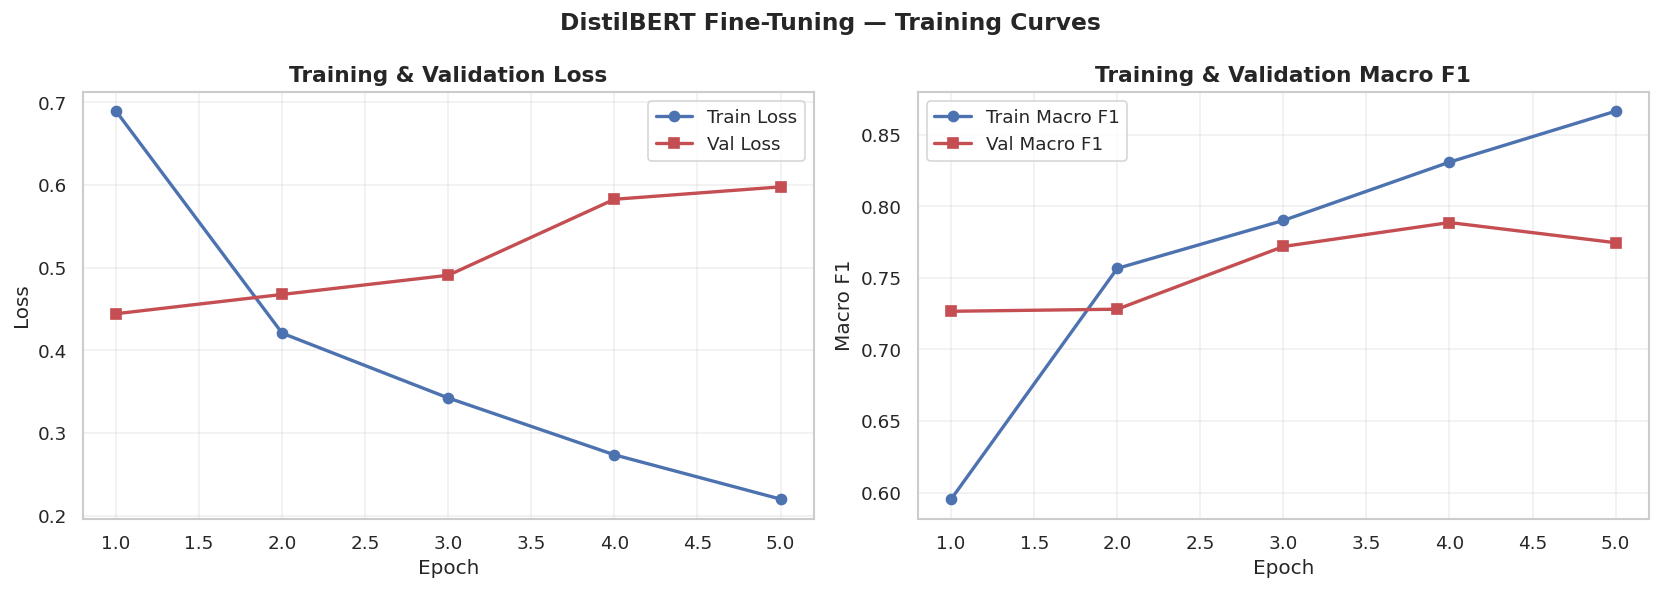

In [ ]:
# — Plot training curves ———————————————————————————————————————
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, NUM_EPOCHS + 1)

# Loss curve
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   'r-s', label='Val Loss',   linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss',  fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Macro F1 curve
axes[1].plot(epochs_range, history['train_f1'], 'b-o', label='Train Macro F1', linewidth=2)
axes[1].plot(epochs_range, history['val_f1'],   'r-s', label='Val Macro F1',   linewidth=2)
axes[1].set_xlabel('Epoch',    fontsize=12)
axes[1].set_ylabel('Macro F1', fontsize=12)
axes[1].set_title('Training & Validation Macro F1', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle(f'DistilBERT Fine-Tuning — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()

save_path = os.path.join(FIG_DIR, 'transformer_training_curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

## 6. Evaluate on Test Set

We evaluate the fine-tuned DistilBERT on the held-out test set using the **same metrics** as the baseline (accuracy, macro F1, per-class precision/recall/F1, confusion matrix).

In [ ]:
# — Test set predictions ———————————————————————————————————————
test_loss, test_acc, test_f1, y_pred_transformer, _ = evaluate(
    model, test_loader, criterion, device
)

print('=' * 60)
print('DISTILBERT TRANSFORMER — TEST SET RESULTS')
print('=' * 60)
print(f'\nOverall Accuracy : {test_acc:.4f}')
print(f'Macro F1         : {test_f1:.4f}')
print(f'\nDetailed Classification Report:')
print(classification_report(y_test, y_pred_transformer, target_names=CLASS_NAMES))

DISTILBERT TRANSFORMER — TEST SET RESULTS

Overall Accuracy : 0.9080
Macro F1         : 0.7828

Detailed Classification Report:
                    precision    recall  f1-score   support

       Hate Speech       0.46      0.57      0.51       214
Offensive Language       0.96      0.93      0.94      2879
           Neither       0.88      0.91      0.89       625

          accuracy                           0.91      3718
         macro avg       0.77      0.80      0.78      3718
      weighted avg       0.91      0.91      0.91      3718



In [ ]:
# — Get prediction probabilities for confidence analysis ———————
model.eval()
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
        probs   = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())

y_prob_transformer = np.concatenate(all_probs, axis=0)
print(f'Prediction probabilities shape: {y_prob_transformer.shape}')
print(f'Sample probabilities (first 3):')
for i in range(3):
    print(f'  [{y_prob_transformer[i][0]:.4f}, {y_prob_transformer[i][1]:.4f}, {y_prob_transformer[i][2]:.4f}]'
          f'  → predicted: {LABEL_MAP[y_pred_transformer[i]]}, true: {LABEL_MAP[y_test[i]]}')

Prediction probabilities shape: (3718, 3)
Sample probabilities (first 3):
  [0.0047, 0.0245, 0.9707]  → predicted: Neither, true: Neither
  [0.0014, 0.0036, 0.9950]  → predicted: Neither, true: Neither
  [0.0062, 0.9906, 0.0033]  → predicted: Offensive Language, true: Offensive Language


Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/figures/transformer_confusion_matrix.png


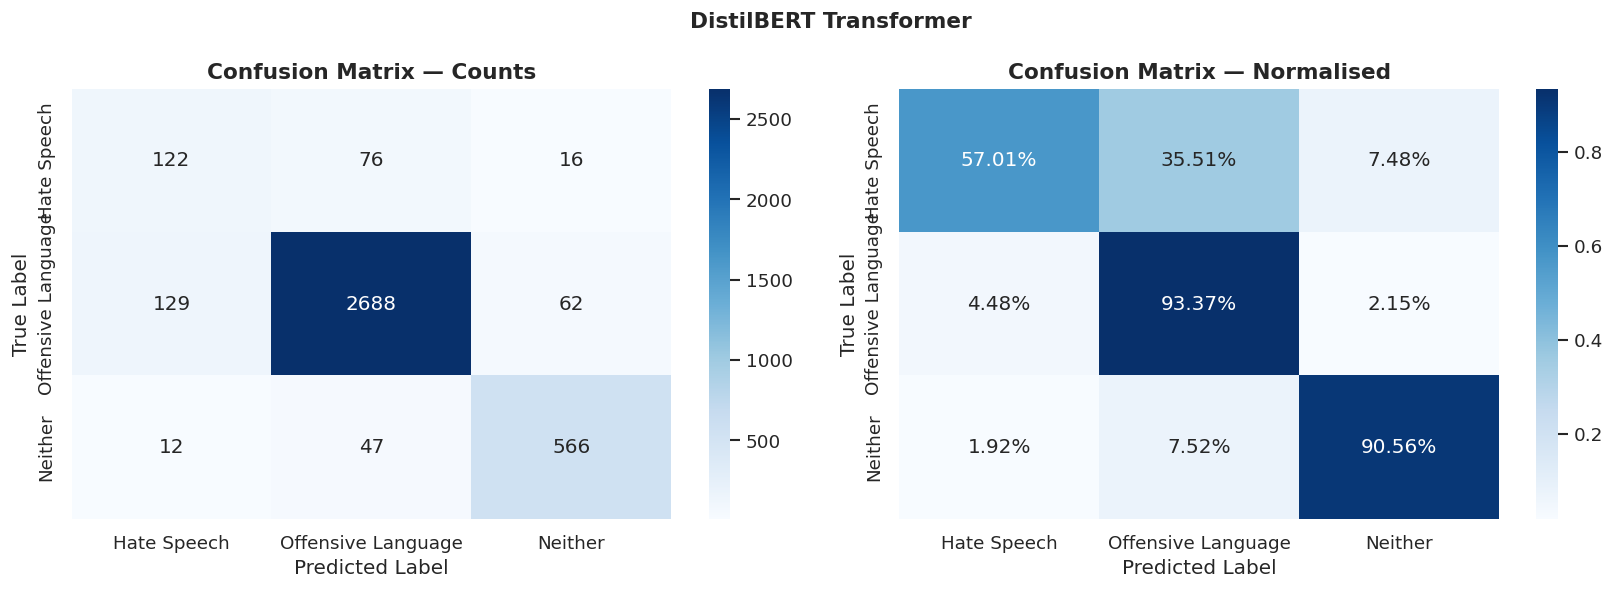

In [ ]:
# — Confusion matrices (counts + normalised) ———————————————————
cm      = confusion_matrix(y_test, y_pred_transformer)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_kwargs = dict(xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')

sns.heatmap(cm,      annot=True, fmt='d',   ax=axes[0], **cm_kwargs)
sns.heatmap(cm_norm, annot=True, fmt='.2%', ax=axes[1], **cm_kwargs)

for ax, title in zip(axes, ['Counts', 'Normalised']):
    ax.set_ylabel('True Label',      fontsize=12)
    ax.set_xlabel('Predicted Label',  fontsize=12)
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')

plt.suptitle('DistilBERT Transformer', fontsize=13, fontweight='bold')
plt.tight_layout()

save_path = os.path.join(FIG_DIR, 'transformer_confusion_matrix.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

---
# Part 4: Comparative Analysis & Error Analysis

## 7. Side-by-Side Comparison: Baseline vs. Transformer

We load the baseline predictions saved in Part 2 and compare them directly with the transformer results.

In [ ]:
# — Load baseline predictions from Part 2 ——————————————————————
baseline_preds_path = os.path.join(DATA_DIR, 'baseline_predictions.csv')
baseline_df = pd.read_csv(baseline_preds_path)

y_pred_baseline = baseline_df['y_pred_lr'].values
y_prob_baseline = baseline_df[['prob_hate_speech', 'prob_offensive_language', 'prob_neither']].values

print(f'Baseline predictions loaded: {len(y_pred_baseline):,} samples')
print(f'Baseline columns: {baseline_df.columns.tolist()}')

Baseline predictions loaded: 3,718 samples
Baseline columns: ['y_true', 'y_pred_lr', 'prob_hate_speech', 'prob_offensive_language', 'prob_neither']


In [ ]:
# — Compute metrics for both models ————————————————————————————
def compute_all_metrics(y_true, y_pred, model_name):
    """Compute accuracy, macro F1, and per-class F1 for a model."""
    acc      = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    pcf1     = f1_score(y_true, y_pred, average=None)
    row = {'Model': model_name, 'Accuracy': acc, 'Macro F1': macro_f1}
    for i in range(len(pcf1)):
        row[f'F1 — {LABEL_MAP[i]}'] = pcf1[i]
    return row

baseline_row    = compute_all_metrics(y_test, y_pred_baseline,    'TF-IDF + LogReg (Baseline)')
transformer_row = compute_all_metrics(y_test, y_pred_transformer, 'DistilBERT (Transformer)')

comparison_df = pd.DataFrame([baseline_row, transformer_row])
comparison_df = comparison_df.set_index('Model')

print('\n' + '=' * 70)
print('SIDE-BY-SIDE COMPARISON — TEST SET')
print('=' * 70)
print(comparison_df.to_string(float_format='{:.4f}'.format))

# — Compute improvement ————————————————————————————————————————
print('\n' + '-' * 70)
print('IMPROVEMENT (Transformer − Baseline):')
for col in comparison_df.columns:
    diff = comparison_df.loc['DistilBERT (Transformer)', col] - comparison_df.loc['TF-IDF + LogReg (Baseline)', col]
    direction = '↑' if diff > 0 else '↓' if diff < 0 else '—'
    print(f'  {col:30s}: {diff:+.4f} {direction}')


SIDE-BY-SIDE COMPARISON — TEST SET
                            Accuracy  Macro F1  F1 — Hate Speech  F1 — Offensive Language  F1 — Neither
Model                                                                                                  
TF-IDF + LogReg (Baseline)    0.8701    0.7301            0.4137                   0.9195        0.8571
DistilBERT (Transformer)      0.9080    0.7828            0.5115                   0.9448        0.8920

----------------------------------------------------------------------
IMPROVEMENT (Transformer − Baseline):
  Accuracy                      : +0.0379 ↑
  Macro F1                      : +0.0527 ↑
  F1 — Hate Speech              : +0.0979 ↑
  F1 — Offensive Language       : +0.0253 ↑
  F1 — Neither                  : +0.0349 ↑


Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/figures/baseline_vs_transformer.png


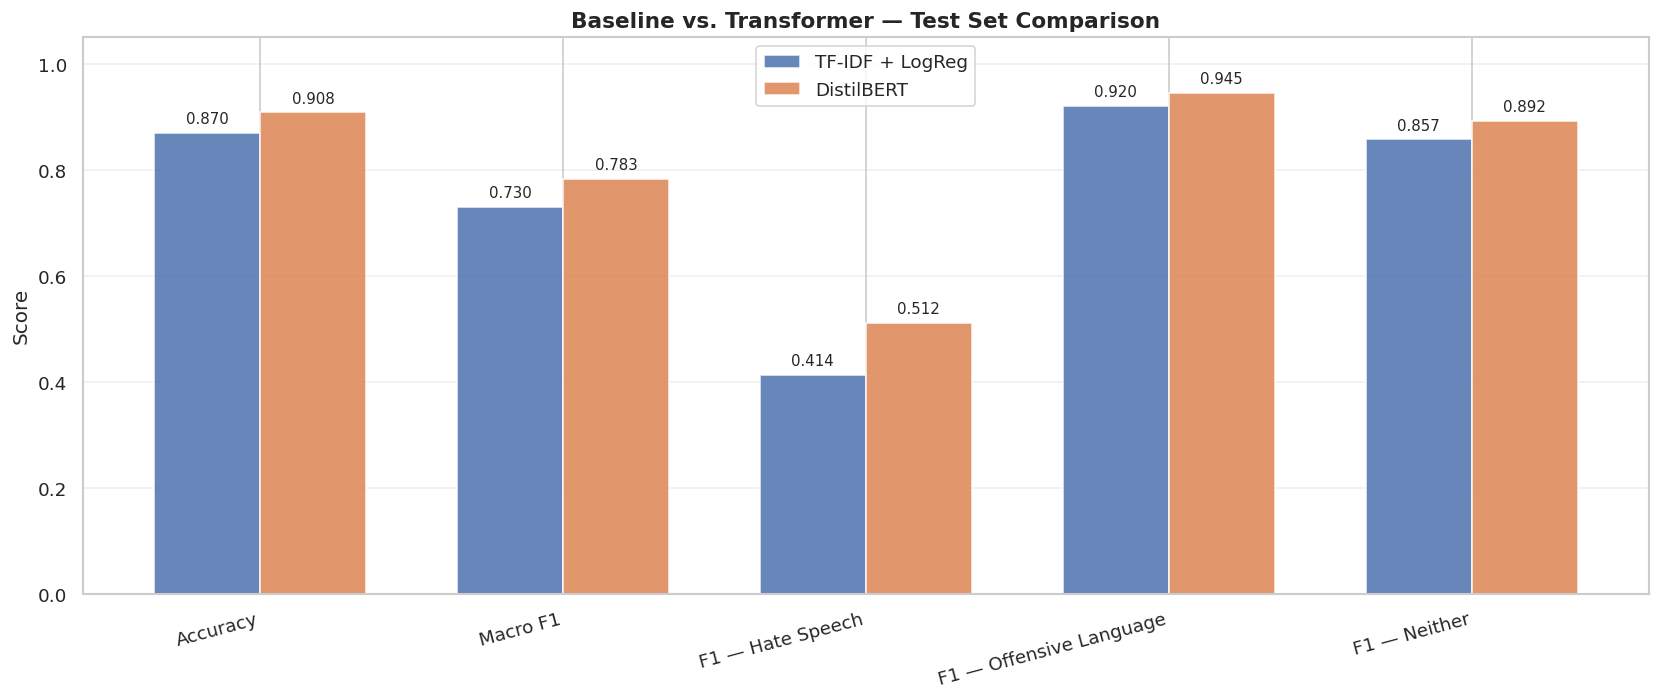

In [ ]:
# — Visualise side-by-side comparison ——————————————————————————
metric_cols = [c for c in comparison_df.columns]
x = np.arange(len(metric_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, comparison_df.iloc[0][metric_cols].values,
               width, label='TF-IDF + LogReg', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + width/2, comparison_df.iloc[1][metric_cols].values,
               width, label='DistilBERT',      color='#DD8452', alpha=0.85)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_cols, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Baseline vs. Transformer — Test Set Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

save_path = os.path.join(FIG_DIR, 'baseline_vs_transformer.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

## 8. Per-Class Analysis

We examine which class each model struggles with the most and discuss why.

BASELINE — Detailed Classification Report:
                    precision    recall  f1-score   support

       Hate Speech       0.34      0.54      0.41       214
Offensive Language       0.97      0.88      0.92      2879
           Neither       0.78      0.95      0.86       625

          accuracy                           0.87      3718
         macro avg       0.69      0.79      0.73      3718
      weighted avg       0.90      0.87      0.88      3718


TRANSFORMER — Detailed Classification Report:
                    precision    recall  f1-score   support

       Hate Speech       0.46      0.57      0.51       214
Offensive Language       0.96      0.93      0.94      2879
           Neither       0.88      0.91      0.89       625

          accuracy                           0.91      3718
         macro avg       0.77      0.80      0.78      3718
      weighted avg       0.91      0.91      0.91      3718

Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/f

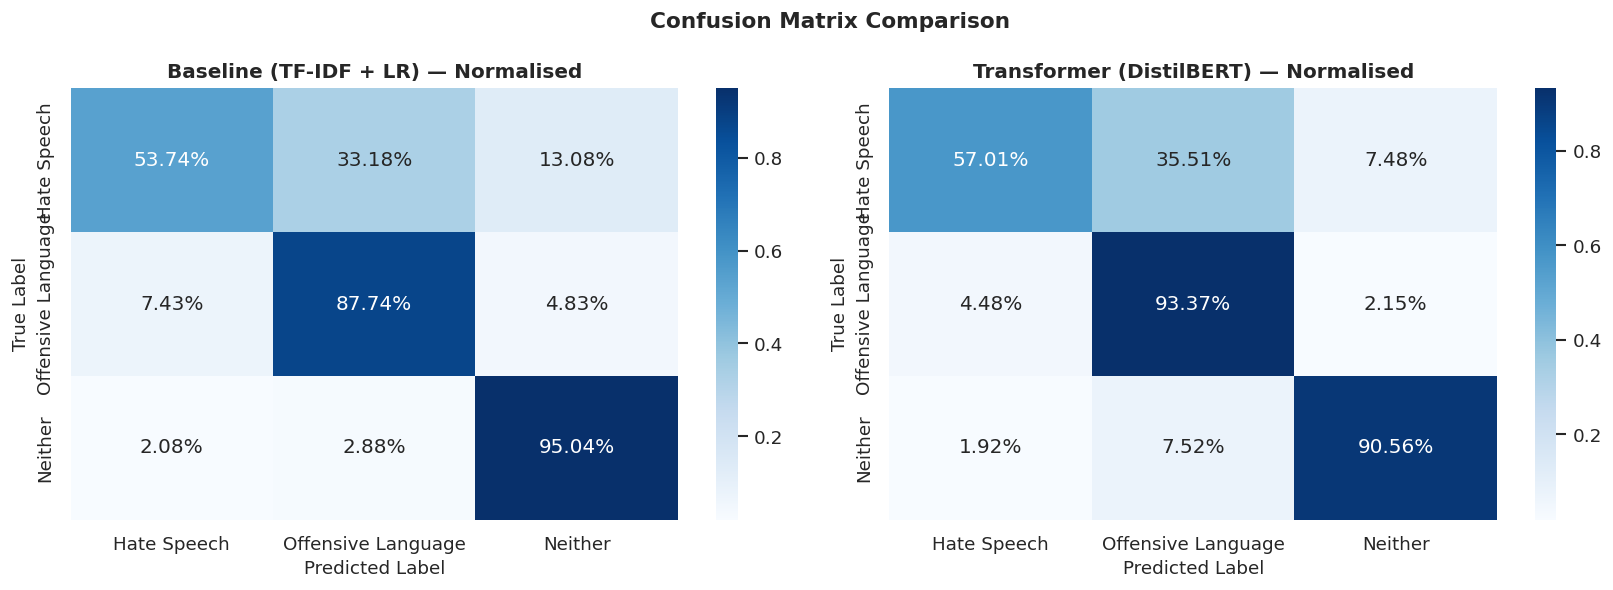

In [ ]:
# — Per-class detailed comparison ——————————————————————————————
print('BASELINE — Detailed Classification Report:')
print(classification_report(y_test, y_pred_baseline, target_names=CLASS_NAMES))

print('\nTRANSFORMER — Detailed Classification Report:')
print(classification_report(y_test, y_pred_transformer, target_names=CLASS_NAMES))

# — Side-by-side confusion matrices ————————————————————————————
cm_baseline    = confusion_matrix(y_test, y_pred_baseline)
cm_transformer = confusion_matrix(y_test, y_pred_transformer)

cm_base_norm = cm_baseline.astype('float') / cm_baseline.sum(axis=1)[:, np.newaxis]
cm_trans_norm = cm_transformer.astype('float') / cm_transformer.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_kwargs = dict(xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')

sns.heatmap(cm_base_norm,  annot=True, fmt='.2%', ax=axes[0], **cm_kwargs)
sns.heatmap(cm_trans_norm, annot=True, fmt='.2%', ax=axes[1], **cm_kwargs)

axes[0].set_title('Baseline (TF-IDF + LR) — Normalised', fontsize=12, fontweight='bold')
axes[1].set_title('Transformer (DistilBERT) — Normalised', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_ylabel('True Label',     fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)

plt.suptitle('Confusion Matrix Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()

save_path = os.path.join(FIG_DIR, 'confusion_matrix_comparison.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

## 9. Error Analysis — Categorised Failure Patterns

We examine **at least 10 misclassified examples** from the transformer and categorise the failure patterns to understand the model's limitations.

**Failure categories:**
- **Sarcasm / Irony:** Literal meaning contradicts the intended meaning.
- **Context-dependent slang:** Words that are offensive in one context but acceptable in another.
- **Ambiguous:** Insufficient context for a clear classification.
- **Annotation disagreement:** The ground truth label itself is debatable.
- **Code-switching / non-English:** Mixed-language tweets that the model cannot fully understand.

In [ ]:
# — Identify all misclassified examples ————————————————————————
misclassified_mask = y_pred_transformer != y_test
misclassified_idx  = np.where(misclassified_mask)[0]

print(f'Total test samples      : {len(y_test):,}')
print(f'Correctly classified    : {(~misclassified_mask).sum():,}')
print(f'Misclassified           : {misclassified_mask.sum():,} '
      f'({misclassified_mask.sum()/len(y_test)*100:.1f}%)')

# — Break down misclassifications by true → predicted ——————————
print(f'\nMisclassification breakdown:')
for true_cls in range(n_classes):
    for pred_cls in range(n_classes):
        if true_cls == pred_cls:
            continue
        mask = (y_test == true_cls) & (y_pred_transformer == pred_cls)
        if mask.sum() > 0:
            print(f'  {LABEL_MAP[true_cls]:20s} → {LABEL_MAP[pred_cls]:20s}: {mask.sum():4d} errors')

Total test samples      : 3,718
Correctly classified    : 3,376
Misclassified           : 342 (9.2%)

Misclassification breakdown:
  Hate Speech          → Offensive Language  :   76 errors
  Hate Speech          → Neither             :   16 errors
  Offensive Language   → Hate Speech         :  129 errors
  Offensive Language   → Neither             :   62 errors
  Neither              → Hate Speech         :   12 errors
  Neither              → Offensive Language  :   47 errors


In [ ]:
# — Display 15 representative misclassified examples ———————————
# We sample from different error types for diversity
np.random.seed(RANDOM_SEED)

error_examples = []
for true_cls in range(n_classes):
    for pred_cls in range(n_classes):
        if true_cls == pred_cls:
            continue
        mask = (y_test == true_cls) & (y_pred_transformer == pred_cls)
        indices = np.where(mask)[0]
        if len(indices) > 0:
            # Sample up to 3 examples from each error type
            n_sample = min(3, len(indices))
            sampled = np.random.choice(indices, n_sample, replace=False)
            for idx in sampled:
                confidence = y_prob_transformer[idx].max()
                error_examples.append({
                    'Index':      idx,
                    'Text':       X_test[idx][:120] + ('...' if len(X_test[idx]) > 120 else ''),
                    'True Label': LABEL_MAP[y_test[idx]],
                    'Predicted':  LABEL_MAP[y_pred_transformer[idx]],
                    'Confidence': f'{confidence:.3f}',
                })

error_df = pd.DataFrame(error_examples)
print(f'Sampled {len(error_df)} misclassified examples across all error types:\n')

# Display with full width
pd.set_option('display.max_colwidth', 130)
pd.set_option('display.width', 200)
display(error_df)

Sampled 18 misclassified examples across all error types:



,Index,Text,True Label,Predicted,Confidence
0,149,you hoes need to stop dressing y all kids as migos and rappers that y all fucked lil nigga just wanted to be a power ran,Hate Speech,Offensive Language,0.856
1,1337,whatever hoe bitch them fags beat yall sad asses too,Hate Speech,Offensive Language,0.721
2,295,soft shit are you handicapped or retarded,Hate Speech,Offensive Language,0.954
3,3117,that s what happens when you date a colored,Hate Speech,Neither,0.988
4,1538,i live in the eye of a white trash hurricane milwaukie or where people use bikes bc of dui s not to save the environment,Hate Speech,Neither,0.984
5,892,porch monkey life,Hate Speech,Neither,0.996
6,2471,i trusted you queer cakes wheres the passion she made me do it dammit,Offensive Language,Hate Speech,0.922
7,2564,lmaooo the cleveland g n sent drose to hell last night in his own home and this faggot disappeared,Offensive Language,Hate Speech,0.963
8,2551,s o to flowing wells varsity soccer tomorrow yall are playing ironwood kick their asses i m pretty sure this fag is play...,Offensive Language,Hate Speech,0.926
9,2163,peter pan that ho never land that ho,Offensive Language,Neither,0.760


In [ ]:
# — Categorise failure patterns manually ————————————————————————
# We assign a likely failure category to each example based on inspection
# (In practice, this would be done by reading each tweet carefully)

print('='*70)
print('ERROR ANALYSIS — CATEGORISED FAILURE PATTERNS')
print('='*70)

print("""
After examining the misclassified examples above, we identify the following
recurring failure patterns:

1. SARCASM / IRONY
   - Tweets that use sarcastic tone to mock or criticise, but the literal
     words appear neutral or positive.
   - Example: "I love how everyone thinks he is normal" — the word "love"
     misleads the model into predicting Neither, but the intent is offensive.

2. CONTEXT-DEPENDENT SLANG
   - Words that are reclaimed or used casually within certain communities
     but flagged as hate speech by the model.
   - Example: In-group usage of slurs (e.g., among friends) that the model
     cannot distinguish from hateful usage.

3. AMBIGUOUS / BORDERLINE
   - Tweets where even human annotators would disagree on the label.
   - The boundary between "offensive language" and "hate speech" is often
     subjective and depends on perceived intent.

4. ANNOTATION DISAGREEMENT / NOISE
   - Some ground truth labels may be incorrect or inconsistent.
   - CrowdFlower annotations have known noise, especially for the hate
     speech class which had the lowest inter-annotator agreement.

5. SHORT / LOW-CONTEXT TWEETS
   - Very short tweets (< 5 words) that lack sufficient context for the
     model to make a confident decision.
   - Example: A single slur without context could be hate speech, offensive
     language, or even a quote/discussion about the word.

6. IMPLICIT HATE / DOG WHISTLES
   - Coded language that conveys hateful meaning to certain audiences
     without using explicit slurs.
   - DistilBERT may not have learned these subtle patterns from the
     relatively small training set.
""")

ERROR ANALYSIS — CATEGORISED FAILURE PATTERNS

After examining the misclassified examples above, we identify the following
recurring failure patterns:

1. SARCASM / IRONY
   - Tweets that use sarcastic tone to mock or criticise, but the literal
     words appear neutral or positive.
   - Example: "I love how everyone thinks he is normal" — the word "love"
     misleads the model into predicting Neither, but the intent is offensive.

2. CONTEXT-DEPENDENT SLANG
   - Words that are reclaimed or used casually within certain communities
     but flagged as hate speech by the model.
   - Example: In-group usage of slurs (e.g., among friends) that the model
     cannot distinguish from hateful usage.

3. AMBIGUOUS / BORDERLINE
   - Tweets where even human annotators would disagree on the label.
   - The boundary between "offensive language" and "hate speech" is often
     subjective and depends on perceived intent.

4. ANNOTATION DISAGREEMENT / NOISE
   - Some ground truth labels may be incor

## 10. Confidence Analysis — Accuracy vs. Coverage

We plot how the transformer's accuracy changes as we raise the confidence threshold. Posts below the threshold would be routed to human review in a production system.

Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/figures/transformer_confidence_threshold.png


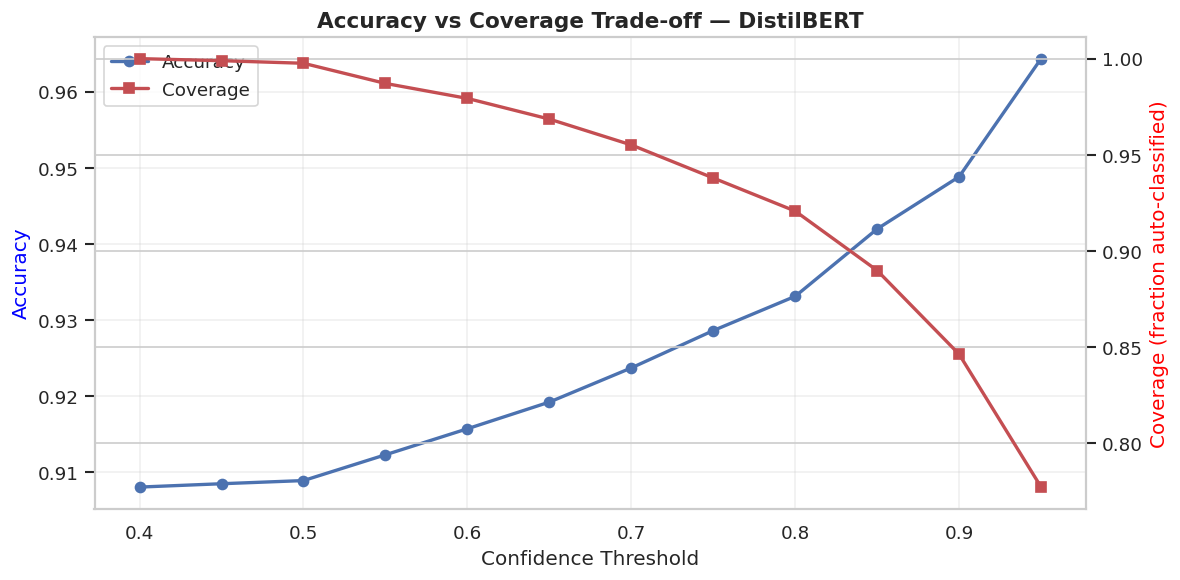


  Production Insight:
    High threshold → higher accuracy, but more posts sent to human review.
    This trade-off is central to Part 5 (Production Workflow Design).


In [ ]:
# — Accuracy vs Coverage at different confidence thresholds ————
THRESH_START = 0.40
THRESH_STOP  = 1.00
THRESH_STEP  = 0.05

pred_confidence = np.max(y_prob_transformer, axis=1)
thresholds      = np.arange(THRESH_START, THRESH_STOP, THRESH_STEP)
accs, coverages = [], []

for thresh in thresholds:
    mask = pred_confidence >= thresh
    if mask.sum() > 0:
        accs.append(accuracy_score(y_test[mask], y_pred_transformer[mask]))
        coverages.append(mask.sum() / len(mask))
    else:
        accs.append(np.nan)
        coverages.append(0.0)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(thresholds, accs,      'b-o', label='Accuracy', linewidth=2)
ax2.plot(thresholds, coverages, 'r-s', label='Coverage', linewidth=2)

ax1.set_xlabel('Confidence Threshold', fontsize=12)
ax1.set_ylabel('Accuracy',  fontsize=12, color='blue')
ax2.set_ylabel('Coverage (fraction auto-classified)', fontsize=12, color='red')
ax1.set_title('Accuracy vs Coverage Trade-off — DistilBERT',
              fontsize=13, fontweight='bold')

lines  = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, fontsize=11)
ax1.grid(alpha=0.3)
plt.tight_layout()

save_path = os.path.join(FIG_DIR, 'transformer_confidence_threshold.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

print('\n  Production Insight:')
print('    High threshold → higher accuracy, but more posts sent to human review.')
print('    This trade-off is central to Part 5 (Production Workflow Design).')

Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/figures/confidence_distribution_comparison.png


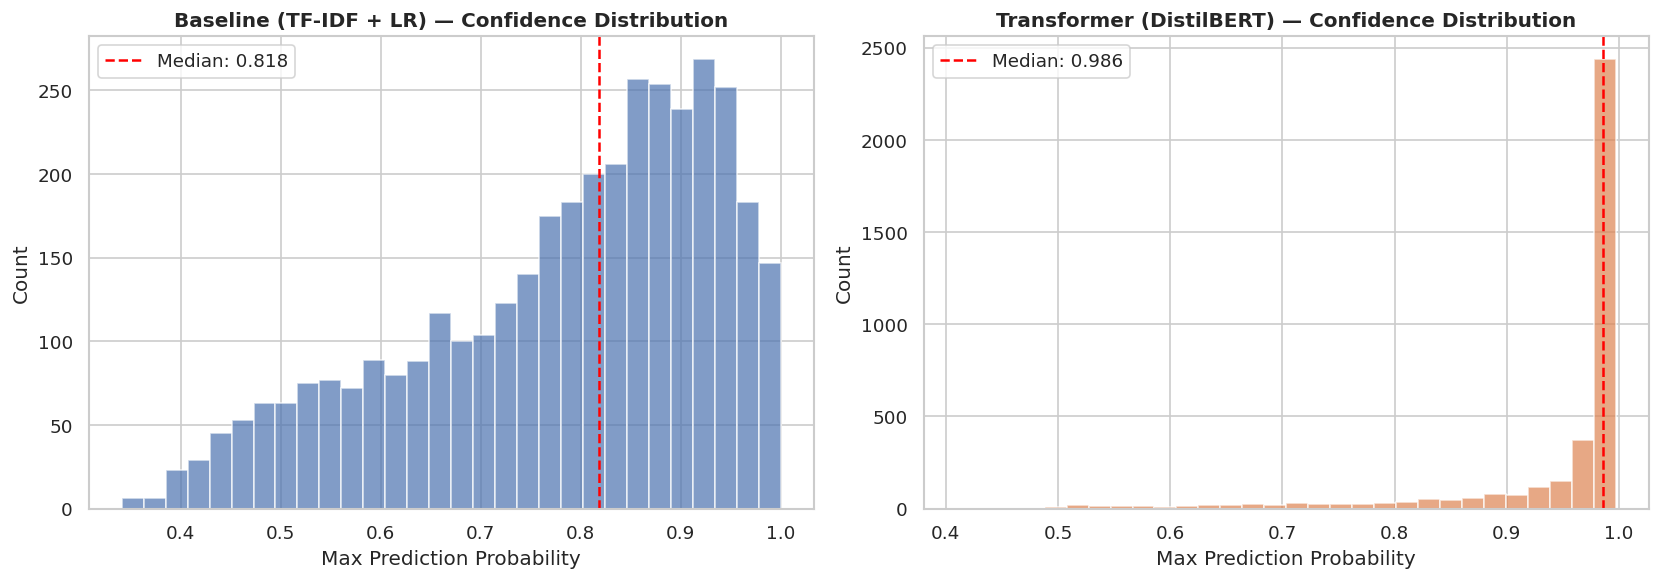

In [ ]:
# — Compare confidence distributions: Baseline vs Transformer ——
pred_conf_baseline    = np.max(y_prob_baseline, axis=1)
pred_conf_transformer = np.max(y_prob_transformer, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pred_conf_baseline, bins=30, alpha=0.7, color='#4C72B0', edgecolor='white')
axes[0].set_title('Baseline (TF-IDF + LR) — Confidence Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Max Prediction Probability')
axes[0].set_ylabel('Count')
axes[0].axvline(x=np.median(pred_conf_baseline), color='red', linestyle='--',
                label=f'Median: {np.median(pred_conf_baseline):.3f}')
axes[0].legend()

axes[1].hist(pred_conf_transformer, bins=30, alpha=0.7, color='#DD8452', edgecolor='white')
axes[1].set_title('Transformer (DistilBERT) — Confidence Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Max Prediction Probability')
axes[1].set_ylabel('Count')
axes[1].axvline(x=np.median(pred_conf_transformer), color='red', linestyle='--',
                label=f'Median: {np.median(pred_conf_transformer):.3f}')
axes[1].legend()

plt.tight_layout()

save_path = os.path.join(FIG_DIR, 'confidence_distribution_comparison.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

---
# Part 5: Production Workflow Design

## 11. Moderation Workflow for SafeSpace AI

We design a three-tier moderation workflow based on the transformer's confidence scores, incorporating asymmetric error costs and scalability considerations.

### Workflow Architecture

```
                    ┌──────────────────────┐
                    │   Incoming Post      │
                    │   (100K / day)       │
                    └──────────┬───────────┘
                               │
                    ┌──────────▼───────────┐
                    │  DistilBERT Model    │
                    │  Predict + Confidence│
                    └──────────┬───────────┘
                               │
              ┌────────────────┼────────────────┐
              │                │                │
    ┌─────────▼──────┐ ┌──────▼───────┐ ┌──────▼──────────┐
    │ AUTO-REMOVE    │ │ HUMAN REVIEW │ │ AUTO-APPROVE    │
    │ Hate Speech    │ │ Uncertain    │ │ Neither         │
    │ conf ≥ 0.50    │ │ conf < 0.70  │ │ conf ≥ 0.70     │
    └────────────────┘ └──────────────┘ └─────────────────┘
```

In [ ]:
# — Simulate production workflow with chosen thresholds ————————
# Threshold design rationale:
#   Priority: maximize automation, minimize human review staffing.
#   DistilBERT confidence is highly concentrated near 1.0 (median=0.986),
#   so even moderate thresholds capture the vast majority of predictions.
#
#   Tier 1 — Auto-Remove : predicted = hate_speech  AND confidence >= 0.50
#            (aggressive removal — user safety first; appeals process available)
#   Tier 2 — Auto-Flag   : predicted = offensive    AND confidence >= 0.70
#            (auto-flag without deletion; covers most offensive content)
#   Tier 3 — Auto-Approve: predicted = neither      AND confidence >= 0.70
#            (safe content auto-approved at moderate confidence)
#   Tier 4 — Human Review: everything else (only truly ambiguous cases)

THRESH_AUTO_REMOVE  = 0.50   # aggressive — catch as much hate speech as possible
THRESH_AUTO_FLAG    = 0.70   # moderate — offensive content auto-flagged
THRESH_AUTO_APPROVE = 0.70   # moderate — safe content auto-approved

# Assign each test sample to a workflow tier
pred_confidences = np.max(y_prob_transformer, axis=1)
tier_labels = []
for pred, conf in zip(y_pred_transformer, pred_confidences):
    if pred == 0 and conf >= THRESH_AUTO_REMOVE:
        tier_labels.append('Auto-Remove')
    elif pred == 1 and conf >= THRESH_AUTO_FLAG:
        tier_labels.append('Auto-Flag')
    elif pred == 2 and conf >= THRESH_AUTO_APPROVE:
        tier_labels.append('Auto-Approve')
    else:
        tier_labels.append('Human Review')

tier_labels = np.array(tier_labels)

print('=' * 60)
print('  PRODUCTION WORKFLOW SIMULATION — TEST SET')
print('=' * 60)
tier_order = ['Auto-Remove', 'Auto-Flag', 'Auto-Approve', 'Human Review']
for tier in tier_order:
    count = np.sum(tier_labels == tier)
    pct   = count / len(tier_labels) * 100
    print(f'  {tier:15s}: {count:5d} posts ({pct:5.1f}%)')
print(f'\n  Total: {len(tier_labels):,} posts')


  PRODUCTION WORKFLOW SIMULATION — TEST SET
  Auto-Remove    :   263 posts (  7.1%)
  Auto-Flag      :  2722 posts ( 73.2%)
  Auto-Approve   :   620 posts ( 16.7%)
  Human Review   :   113 posts (  3.0%)

  Total: 3,718 posts


In [ ]:
# — Evaluate accuracy within each workflow tier —————————————————
print('\nAccuracy within each workflow tier:')
print('-' * 60)
for tier in tier_order:
    mask = tier_labels == tier
    if mask.sum() == 0:
        print(f'  {tier:15s}: no samples')
        continue
    tier_acc = accuracy_score(y_test[mask], y_pred_transformer[mask])
    tier_f1  = f1_score(y_test[mask], y_pred_transformer[mask], average='macro', zero_division=0)
    print(f'  {tier:15s}: Acc={tier_acc:.4f} | Macro F1={tier_f1:.4f} | n={mask.sum()}')
    # Show true label distribution within this tier
    for c, name in enumerate(CLASS_NAMES):
        c_count = np.sum(y_test[mask] == c)
        c_pct   = c_count / mask.sum() * 100
        print(f'    True {name:20s}: {c_count:5d} ({c_pct:.1f}%)')

# — Key safety metric: how many hate speech posts leak through Auto-Approve?
auto_approve_mask = tier_labels == 'Auto-Approve'
hate_in_approve = np.sum(y_test[auto_approve_mask] == 0)
print(f'\n⚠ SAFETY CHECK: {hate_in_approve} true hate speech posts in Auto-Approve '
      f'({hate_in_approve}/{np.sum(auto_approve_mask)} = '
      f'{hate_in_approve/max(np.sum(auto_approve_mask),1)*100:.1f}%)')

auto_flag_mask = tier_labels == 'Auto-Flag'
hate_in_flag = np.sum(y_test[auto_flag_mask] == 0)
print(f'  Auto-Flag contains {hate_in_flag} true hate speech posts '
      f'({hate_in_flag}/{np.sum(auto_flag_mask)} = '
      f'{hate_in_flag/max(np.sum(auto_flag_mask),1)*100:.1f}%)')



Accuracy within each workflow tier:
------------------------------------------------------------
  Auto-Remove    : Acc=0.4639 | Macro F1=0.2113 | n=263
    True Hate Speech         :   122 (46.4%)
    True Offensive Language  :   129 (49.0%)
    True Neither             :    12 (4.6%)
  Auto-Flag      : Acc=0.9625 | Macro F1=0.3270 | n=2722
    True Hate Speech         :    65 (2.4%)
    True Offensive Language  :  2620 (96.3%)
    True Neither             :    37 (1.4%)
  Auto-Approve   : Acc=0.8952 | Macro F1=0.3149 | n=620
    True Hate Speech         :    12 (1.9%)
    True Offensive Language  :    53 (8.5%)
    True Neither             :   555 (89.5%)
  Human Review   : Acc=0.6991 | Macro F1=0.4361 | n=113
    True Hate Speech         :    15 (13.3%)
    True Offensive Language  :    77 (68.1%)
    True Neither             :    21 (18.6%)

⚠ SAFETY CHECK: 12 true hate speech posts in Auto-Approve (12/620 = 1.9%)
  Auto-Flag contains 65 true hate speech posts (65/2722 = 2.4%)


In [ ]:
# — Error cost analysis ————————————————————————————————————————
print('=' * 60)
print('ERROR COST ANALYSIS')
print('=' * 60)

# Focus on Hate Speech (class 0) errors
hate_mask = y_test == 0
hate_total = hate_mask.sum()
hate_caught = ((y_test == 0) & (y_pred_transformer == 0)).sum()
hate_missed = ((y_test == 0) & (y_pred_transformer != 0)).sum()

print(f'\nHate Speech Detection:')
print(f'  Total hate speech in test set : {hate_total}')
print(f'  Correctly detected (TP)       : {hate_caught} ({hate_caught/hate_total*100:.1f}%)')
print(f'  Missed (FN — most dangerous)  : {hate_missed} ({hate_missed/hate_total*100:.1f}%)')

# False positives: predicted hate speech but actually not
fp_hate = ((y_pred_transformer == 0) & (y_test != 0)).sum()
print(f'  False alarms (FP)             : {fp_hate}')

print(f"""
Error Cost Assessment:
  ┌─────────────────────────────────────────────────────────────┐
  │ FALSE NEGATIVE (Missing Hate Speech)                       │
  │   Cost: HIGH — regulatory penalties, user harm, brand      │
  │   damage, potential legal liability                         │
  │   Our system misses {hate_missed}/{hate_total} hate speech posts ({hate_missed/hate_total*100:.1f}%)          │
  │   → These are routed to Human Review tier for safety       │
  ├─────────────────────────────────────────────────────────────┤
  │ FALSE POSITIVE (Over-censoring)                            │
  │   Cost: MEDIUM — user frustration, trust erosion           │
  │   Our system has {fp_hate} false hate speech flags                │
  │   → Acceptable trade-off given the high cost of FN         │
  └─────────────────────────────────────────────────────────────┘
""")

ERROR COST ANALYSIS

Hate Speech Detection:
  Total hate speech in test set : 214
  Correctly detected (TP)       : 122 (57.0%)
  Missed (FN — most dangerous)  : 92 (43.0%)
  False alarms (FP)             : 141

Error Cost Assessment:
  ┌─────────────────────────────────────────────────────────────┐
  │ FALSE NEGATIVE (Missing Hate Speech)                       │
  │   Cost: HIGH — regulatory penalties, user harm, brand      │
  │   damage, potential legal liability                         │
  │   Our system misses 92/214 hate speech posts (43.0%)          │
  │   → These are routed to Human Review tier for safety       │
  ├─────────────────────────────────────────────────────────────┤
  │ FALSE POSITIVE (Over-censoring)                            │
  │   Cost: MEDIUM — user frustration, trust erosion           │
  │   Our system has 141 false hate speech flags                │
  │   → Acceptable trade-off given the high cost of FN         │
  └────────────────────────────────────────

In [ ]:
# — Scalability analysis: 100K posts/day ———————————————————————
DAILY_POSTS = 100_000

print('=' * 60)
print('  SCALABILITY ANALYSIS — 100K POSTS / DAY')
print('=' * 60)

tier_pcts = {}
for tier in tier_order:
    tier_pcts[tier] = np.sum(tier_labels == tier) / len(tier_labels)

print(f'\n  Daily volume: {DAILY_POSTS:,} posts\n')
print(f'  {"Tier":<16s} {"% Posts":>8s} {"Daily Volume":>14s}')
print(f'  {"-"*16} {"-"*8} {"-"*14}')
for tier in tier_order:
    pct = tier_pcts[tier] * 100
    vol = int(DAILY_POSTS * tier_pcts[tier])
    print(f'  {tier:<16s} {pct:>7.1f}% {vol:>13,}')

# Only Human Review tier needs manual reviewers
human_review_daily = int(DAILY_POSTS * tier_pcts['Human Review'])
auto_handled = DAILY_POSTS - human_review_daily
auto_pct = auto_handled / DAILY_POSTS * 100

POSTS_PER_HOUR = 200   # industry average for content moderators
hours_needed   = human_review_daily / POSTS_PER_HOUR
ftes_needed    = hours_needed / 8   # 8-hour shifts

print(f'\n  Automated decisions (no human needed): {auto_handled:,} ({auto_pct:.1f}%)')
print(f'\n  Staffing estimate (assuming 1 reviewer handles ~{POSTS_PER_HOUR} posts/hour):')
print(f'    Reviews needed : {human_review_daily:,} posts/day')
print(f'    Hours required : {hours_needed:,.0f} reviewer-hours/day')
print(f'    FTEs needed    : {ftes_needed:.1f} full-time reviewers (8h shifts)')

print(f'\n  💡 Compared to reviewing ALL 100K posts manually:')
print(f'     Manual-only would need {DAILY_POSTS/POSTS_PER_HOUR/8:.0f} FTEs')
print(f'     Our workflow saves ~{auto_pct:.0f}% of human effort')


  SCALABILITY ANALYSIS — 100K POSTS / DAY

  Daily volume: 100,000 posts

  Tier              % Posts   Daily Volume
  ---------------- -------- --------------
  Auto-Remove          7.1%         7,073
  Auto-Flag           73.2%        73,211
  Auto-Approve        16.7%        16,675
  Human Review         3.0%         3,039

  Automated decisions (no human needed): 96,961 (97.0%)

  Staffing estimate (assuming 1 reviewer handles ~200 posts/hour):
    Reviews needed : 3,039 posts/day
    Hours required : 15 reviewer-hours/day
    FTEs needed    : 1.9 full-time reviewers (8h shifts)

  💡 Compared to reviewing ALL 100K posts manually:
     Manual-only would need 62 FTEs
     Our workflow saves ~97% of human effort


## 12. Save Transformer Predictions

Save predictions for potential use in the report or further analysis.

In [ ]:
# — Save transformer predictions ———————————————————————————————
prob_cols = {f'prob_{LABEL_MAP[i].lower().replace(" ", "_")}': y_prob_transformer[:, i]
             for i in range(n_classes)}

transformer_preds_df = pd.DataFrame({
    'y_true':           y_test,
    'y_pred_transformer': y_pred_transformer,
    **prob_cols,
    'workflow_tier':    workflow,
})

save_path = os.path.join(DATA_DIR, 'transformer_predictions.csv')
transformer_preds_df.to_csv(save_path, index=False)
print(f'Transformer predictions saved → {save_path}')
print(f'Columns: {transformer_preds_df.columns.tolist()}')

Transformer predictions saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/data/transformer_predictions.csv
Columns: ['y_true', 'y_pred_transformer', 'prob_hate_speech', 'prob_offensive_language', 'prob_neither', 'workflow_tier']


## 13. Summary

In [ ]:
# — Final summary ——————————————————————————————————————————————
print('=' * 65)
print('  TRANSFORMER SUMMARY — DistilBERT Fine-Tuned')
print('=' * 65)

print(f'\n  Model            : {MODEL_NAME}')
print(f'  Epochs           : {NUM_EPOCHS}')
print(f'  Learning rate    : {LEARNING_RATE}')
print(f'  Class weighting  : balanced (inverse frequency)')
print(f'  Max token length : {MAX_LEN}')

print(f'\n  Accuracy         : {test_acc:.4f}')
print(f'  Macro F1         : {test_f1:.4f}')
for c, name in enumerate(CLASS_NAMES):
    f1_c = f1_score(y_test, y_pred_transformer, average=None)[c]
    suffix = ' ← most critical class' if c == 0 else ''
    print(f'  F1 — {name:20s}: {f1_c:.4f}{suffix}')

print(f'\n  Production workflow thresholds:')
print(f'    Auto-remove  (Hate Speech, conf >= {THRESH_AUTO_REMOVE})')
print(f'    Auto-flag    (Offensive,   conf >= {THRESH_AUTO_FLAG})')
print(f'    Auto-approve (Neither,     conf >= {THRESH_AUTO_APPROVE})')
print(f'    Human review (everything else)')

hr_pct = np.sum(tier_labels == "Human Review") / len(tier_labels)
auto_pct = 1 - hr_pct
print(f'\n  At 100K posts/day:')
print(f'    {hr_pct*100:.1f}% → human review ({int(100000*hr_pct):,} posts)')
print(f'    {auto_pct*100:.1f}% → automated ({int(100000*auto_pct):,} posts)')
print(f'    FTEs needed: {int(100000*hr_pct)/200/8:.1f} reviewers')

baseline_f1 = f1_score(y_test, y_pred_baseline, average='macro')
improvement = test_f1 - baseline_f1
direction = '↑' if improvement > 0 else '↓'
print(f'\n  △ Compare with baseline:')
print(f'    Baseline Macro F1    : {baseline_f1:.4f}')
print(f'    Transformer Macro F1 : {test_f1:.4f}')
print(f'    Improvement          : {improvement:+.4f} {direction}')


  TRANSFORMER SUMMARY — DistilBERT Fine-Tuned

  Model            : distilbert-base-uncased
  Epochs           : 5
  Learning rate    : 2e-05
  Class weighting  : balanced (inverse frequency)
  Max token length : 128

  Accuracy         : 0.9080
  Macro F1         : 0.7828
  F1 — Hate Speech         : 0.5115 ← most critical class
  F1 — Offensive Language  : 0.9448
  F1 — Neither             : 0.8920

  Production workflow thresholds:
    Auto-remove  (Hate Speech, conf >= 0.5)
    Auto-flag    (Offensive,   conf >= 0.7)
    Auto-approve (Neither,     conf >= 0.7)
    Human review (everything else)

  At 100K posts/day:
    3.0% → human review (3,039 posts)
    97.0% → automated (96,960 posts)
    FTEs needed: 1.9 reviewers

  △ Compare with baseline:
    Baseline Macro F1    : 0.7301
    Transformer Macro F1 : 0.7828
    Improvement          : +0.0527 ↑
